## OpenCV Faster RCNN Object Detection 

(375, 500, 3)


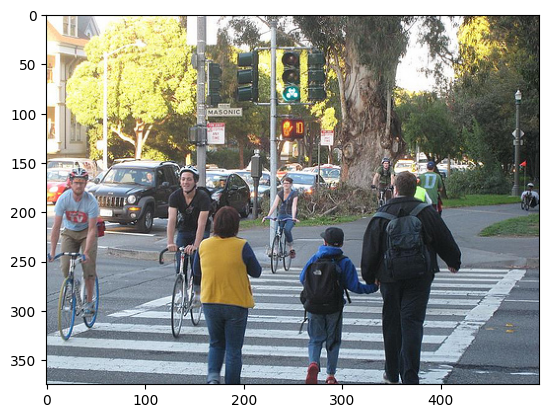

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('demo28.jpg')
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
print(img_rgb.shape)
plt.imshow(img_rgb);

#### Tensorflow에서 Pretrained 된 Inference모델(Frozen graph)와 환경파일을 다운로드 받은 후 이를 이용해 OpenCV에서 Inference 모델 생성
* https://github.com/opencv/opencv/wiki/TensorFlow-Object-Detection-API 에 다운로드 URL 있음.
* pretrained 모델은 http://download.tensorflow.org/models/object_detection/faster_rcnn_resnet50_coco_2018_01_28.tar.gz 에서 다운로드 후 압축 해제
* pretrained 모델을 위한 환경 파일은 https://github.com/opencv/opencv_extra/blob/master/testdata/dnn/faster_rcnn_resnet50_coco_2018_01_28.pbtxt 에서 다운로드 
* download된 모델 파일과 config 파일을 인자로 하여 inference 모델을 DNN에서 로딩함. 

In [2]:
# !mkdir pretrained; cd pretrained
# !wget http://download.tensorflow.org/models/object_detection/faster_rcnn_resnet50_coco_2018_01_28.tar.gz
# !wget https://raw.githubusercontent.com/opencv/opencv_extra/master/testdata/dnn/faster_rcnn_resnet50_coco_2018_01_28.pbtxt
# !cd faster_rcnn_resnet50_coco_2018_01_28; mv faster_rcnn_resnet50_coco_2018_01_28.pbtxt graph.pbtxt

In [3]:
# !pwd
# !ls pretrained/faster_rcnn_resnet50_coco_2018_01_28

In [4]:
# ! mkdir pretrained

In [5]:
# !dir 

#### dnn에서 readNetFromTensorflow()로 tensorflow inference 모델을 로딩

In [ ]:
# cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb', 
                                    #  './pretrained/faster_rcnn_resnet50_coco_2018_01_28/graph.pbtxt')
cv_net = cv2.dnn.readNetFromTensorflow('pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb', 
                                     'pretrained/faster_rcnn_resnet50_coco_2018_01_28/faster_rcnn_resnet50_coco_2018_01_28.pbtxt')                                    

### COCO 데이터 세트의 클래스id별 클래스명 지정. 

In [11]:
# Tensorflow Faster RCNN모델 : 이 소스에서 사용됨
labels_to_names_0 = {0:'person',1:'bicycle',2:'car',3:'motorcycle',4:'airplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',
                    10:'fire hydrant',11:'street sign',12:'stop sign',13:'parking meter',14:'bench',15:'bird',16:'cat',17:'dog',18:'horse',19:'sheep',
                    20:'cow',21:'elephant',22:'bear',23:'zebra',24:'giraffe',25:'hat',26:'backpack',27:'umbrella',28:'shoe',29:'eye glasses',
                    30:'handbag',31:'tie',32:'suitcase',33:'frisbee',34:'skis',35:'snowboard',36:'sports ball',37:'kite',38:'baseball bat',39:'baseball glove',
                    40:'skateboard',41:'surfboard',42:'tennis racket',43:'bottle',44:'plate',45:'wine glass',46:'cup',47:'fork',48:'knife',49:'spoon',
                    50:'bowl',51:'banana',52:'apple',53:'sandwich',54:'orange',55:'broccoli',56:'carrot',57:'hot dog',58:'pizza',59:'donut',
                    60:'cake',61:'chair',62:'couch',63:'potted plant',64:'bed',65:'mirror',66:'dining table',67:'window',68:'desk',69:'toilet',
                    70:'door',71:'tv',72:'laptop',73:'mouse',74:'remote',75:'keyboard',76:'cell phone',77:'microwave',78:'oven',79:'toaster',
                    80:'sink',81:'refrigerator',82:'blender',83:'book',84:'clock',85:'vase',86:'scissors',87:'teddy bear',88:'hair drier',89:'toothbrush',
                    90:'hair brush'}

In [8]:
# OpenCV Yolo 모델 
# labels_to_names_seq = {0:'person',1:'bicycle',2:'car',3:'motorbike',4:'aeroplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',10:'fire hydrant',
#                         11:'stop sign',12:'parking meter',13:'bench',14:'bird',15:'cat',16:'dog',17:'horse',18:'sheep',19:'cow',20:'elephant',
#                         21:'bear',22:'zebra',23:'giraffe',24:'backpack',25:'umbrella',26:'handbag',27:'tie',28:'suitcase',29:'frisbee',30:'skis',
#                         31:'snowboard',32:'sports ball',33:'kite',34:'baseball bat',35:'baseball glove',36:'skateboard',37:'surfboard',38:'tennis racket',39:'bottle',40:'wine glass',
#                         41:'cup',42:'fork',43:'knife',44:'spoon',45:'bowl',46:'banana',47:'apple',48:'sandwich',49:'orange',50:'broccoli',
#                         51:'carrot',52:'hot dog',53:'pizza',54:'donut',55:'cake',56:'chair',57:'sofa',58:'pottedplant',59:'bed',60:'diningtable',
#                         61:'toilet',62:'tvmonitor',63:'laptop',64:'mouse',65:'remote',66:'keyboard',67:'cell phone',68:'microwave',69:'oven',70:'toaster',
#                         71:'sink',72:'refrigerator',73:'book',74:'clock',75:'vase',76:'scissors',77:'teddy bear',78:'hair drier',79:'toothbrush' }

In [9]:
# Tensorflow SSD모델
# labels_to_names = {1:'person',2:'bicycle',3:'car',4:'motorcycle',5:'airplane',6:'bus',7:'train',8:'truck',9:'boat',10:'traffic light',
#                     11:'fire hydrant',12:'street sign',13:'stop sign',14:'parking meter',15:'bench',16:'bird',17:'cat',18:'dog',19:'horse',20:'sheep',
#                     21:'cow',22:'elephant',23:'bear',24:'zebra',25:'giraffe',26:'hat',27:'backpack',28:'umbrella',29:'shoe',30:'eye glasses',
#                     31:'handbag',32:'tie',33:'suitcase',34:'frisbee',35:'skis',36:'snowboard',37:'sports ball',38:'kite',39:'baseball bat',40:'baseball glove',
#                     41:'skateboard',42:'surfboard',43:'tennis racket',44:'bottle',45:'plate',46:'wine glass',47:'cup',48:'fork',49:'knife',50:'spoon',
#                     51:'bowl',52:'banana',53:'apple',54:'sandwich',55:'orange',56:'broccoli',57:'carrot',58:'hot dog',59:'pizza',60:'donut',
#                     61:'cake',62:'chair',63:'couch',64:'potted plant',65:'bed',66:'mirror',67:'dining table',68:'window',69:'desk',70:'toilet',
#                     71:'door',72:'tv',73:'laptop',74:'mouse',75:'remote',76:'keyboard',77:'cell phone',78:'microwave',79:'oven',80:'toaster',
#                     81:'sink',82:'refrigerator',83:'blender',84:'book',85:'clock',86:'vase',87:'scissors',88:'teddy bear',89:'hair drier',90:'toothbrush',
#                     91:'hair brush'}


### 이미지를 입력하여 Object Detection 수행 및 결과를 시각화

(1, 1, 100, 7)
person: 0.9979
person: 0.9970
person: 0.9959
person: 0.9837
backpack: 0.9510
bicycle: 0.9296
traffic light: 0.9051
car: 0.8809
bicycle: 0.8654
traffic light: 0.8403
person: 0.8228
person: 0.7901
backpack: 0.7880
person: 0.7528
car: 0.6270
person: 0.5543
bicycle: 0.5494


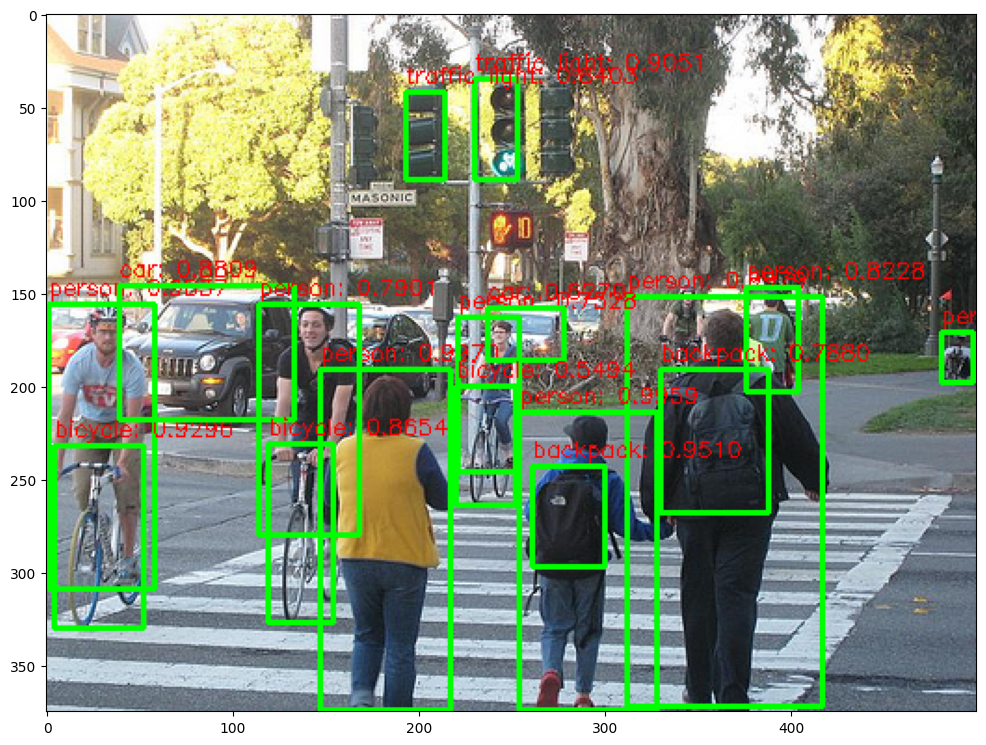

In [12]:
# img : (375, 500, 3)
rows = img.shape[0]
cols = img.shape[1]
draw_img = img.copy()

# 원본 이미지 배열 BGR을 RGB로 변환하여 배열 입력. Tensorflow Faster RCNN은 size를 고정할 필요가 없는 것으로 추정. 
cv_net.setInput(cv2.dnn.blobFromImage(img,swapRB=True,crop=False))

# Object Detection 수행하여 결과를 cvOut으로 반환 
cv_out =cv_net.forward()
print(cv_out.shape)    # (1, 1, 100:detect한 object갯수 , 7 : ,id,score, 좌표 4개)

# bounding box의 테두리와 caption 글자색 지정
green_color=(0, 255, 0)
red_color=(0, 0, 255)

# detected 된 object들을 iteration 하면서 정보 추출
for detection in cv_out[0,0,:,:]:  # 100회 반복
    score = float(detection[2])
    class_id = int(detection[1])
    # detected된 object들의 score(IOU)가 0.5 이상만 추출
    if score > 0.5:
        # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
        left = detection[3] * cols
        top = detection[4] * rows
        right = detection[5] * cols
        bottom = detection[6] * rows
        # labels_to_names_seq 딕셔너리로 class_id값을 클래스명으로 변경.
        caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
        print(caption)
        #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
        cv2.rectangle(draw_img, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
        cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, red_color, 1)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)


#### 단일 이미지의 object detection을 함수로 생성

In [13]:
import time

def get_detected_img(cv_net, img_array, score_threshold, use_copied_array=True, is_print=True):
    
    rows = img_array.shape[0]
    cols = img_array.shape[1]
    
    draw_img = None
    if use_copied_array:
        draw_img = img_array.copy()
    else:
        draw_img = img_array
    
    cv_net.setInput(cv2.dnn.blobFromImage(img_array, swapRB=True, crop=False))
    
    start = time.time()
    cv_out = cv_net.forward()
    
    green_color=(0, 255, 0)
    red_color=(0, 0, 255)

    # detected 된 object들을 iteration 하면서 정보 추출
    for detection in cv_out[0,0,:,:]:
        score = float(detection[2])
        class_id = int(detection[1])
        # detected된 object들의 score가 함수 인자로 들어온 score_threshold 이상만 추출
        if score > score_threshold:
            # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
            left = detection[3] * cols
            top = detection[4] * rows
            right = detection[5] * cols
            bottom = detection[6] * rows
            # labels_to_names 딕셔너리로 class_id값을 클래스명으로 변경. opencv에서는 class_id + 1로 매핑해야함.
            caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
            print(caption)
            #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
            cv2.rectangle(draw_img, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
            cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, red_color, 1)
    if is_print:
        print('Detection 수행시간:',round(time.time() - start, 2),"초")

    return draw_img

image shape: (3000, 4000, 3)
boat: 0.8016
person: 0.8006
airplane: 0.7081
person: 0.6405
boat: 0.6163
boat: 0.6075
person: 0.5085
Detection 수행시간: 9.87 초


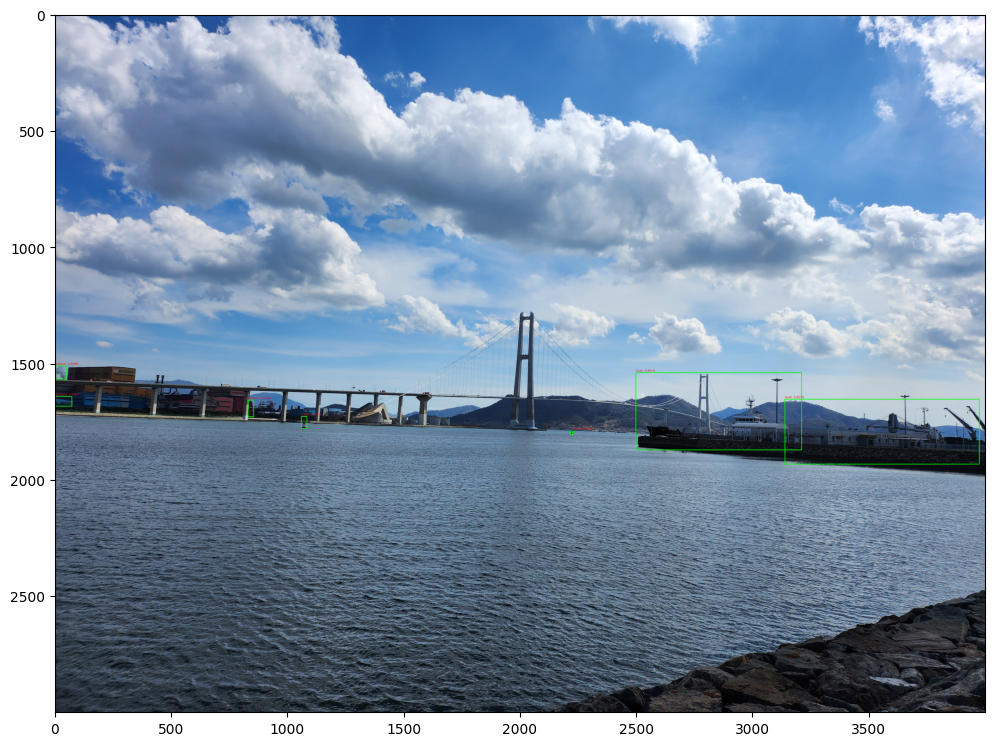

In [14]:
# image 로드 
img = cv2.imread('bridge.jpg')
print('image shape:', img.shape)

# tensorflow inference 모델 로딩
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb', 
                                     './pretrained/faster_rcnn_resnet50_coco_2018_01_28/faster_rcnn_resnet50_coco_2018_01_28.pbtxt')
# Object Detetion 수행 후 시각화 
draw_img = get_detected_img(cv_net, img, score_threshold=0.5, use_copied_array=True, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

### Video Object Detection 수행

#### VideoCapture와 VideoWriter 설정하기
* VideoCapture를 이용하여 Video를 frame별로 capture 할 수 있도록 설정
* VideoCapture의 속성을 이용하여 Video Frame의 크기 및 FPS 설정. 
* VideoWriter를 위한 인코딩 코덱 설정 및 영상 write를 위한 설정 

In [ ]:
video_input_path = 'sample-5s.mp4'    # https://samplelib.com/preview/mp4/sample-5s.mp4
video_output_path = 'sample-5s_out.avi'



cap = cv2.VideoCapture(video_input_path)

codec = cv2.VideoWriter_fourcc(*'XVID')

vid_size = (round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))) 
vid_fps = cap.get(cv2.CAP_PROP_FPS )
    
vid_writer = cv2.VideoWriter(video_output_path, codec, vid_fps, vid_size) 

frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print('총 Frame 갯수:', frame_cnt)

총 Frame 갯수: 171


##### 총 Frame 별로 iteration 하면서 Object Detection 수행. 개별 frame별로 단일 이미지 Object Detection과 유사 

In [ ]:
# 171프레임 : CPU 약 9분 소요
# bounding box의 테두리와 caption 글자색 지정
green_color=(0, 255, 0)
red_color=(0, 0, 255)

frame_index = 0
while True:

    hasFrame, img_frame = cap.read()
    if not hasFrame:
        print('더 이상 처리할 frame이 없습니다.')
        break

    rows = img_frame.shape[0]
    cols = img_frame.shape[1]
    # 원본 이미지 배열 BGR을 RGB로 변환하여 배열 입력
    cv_net.setInput(cv2.dnn.blobFromImage(img_frame,  swapRB=True, crop=False))
    
    start= time.time()
    # Object Detection 수행하여 결과를 cv_out으로 반환 
    cv_out = cv_net.forward()
    # frame_index = 0
    # detected 된 object들을 iteration 하면서 정보 추출
    for detection in cv_out[0,0,:,:]:
        score = float(detection[2])
        class_id = int(detection[1])
        # detected된 object들의 score가 0.5 이상만 추출
        if score > 0.5:
            # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
            left = detection[3] * cols
            top = detection[4] * rows
            right = detection[5] * cols
            bottom = detection[6] * rows
            # labels_to_names_0딕셔너리로 class_id값을 클래스명으로 변경.
            caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
            #print(class_id, caption)
            #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
            cv2.rectangle(img_frame, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
            cv2.putText(img_frame, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, red_color, 1)
    frame_index +=1
    print(frame_index,' : Detection 수행 시간:', round(time.time()-start, 2),'초')
    vid_writer.write(img_frame)
# end of while loop

vid_writer.release()
cap.release()   

1  : Detection 수행 시간: 2.15 초
2  : Detection 수행 시간: 1.85 초
3  : Detection 수행 시간: 1.87 초
4  : Detection 수행 시간: 1.98 초
5  : Detection 수행 시간: 2.55 초
6  : Detection 수행 시간: 2.77 초
7  : Detection 수행 시간: 2.81 초
8  : Detection 수행 시간: 2.78 초
9  : Detection 수행 시간: 3.14 초
10  : Detection 수행 시간: 2.79 초
11  : Detection 수행 시간: 2.86 초
12  : Detection 수행 시간: 2.92 초
13  : Detection 수행 시간: 2.86 초
14  : Detection 수행 시간: 2.94 초
15  : Detection 수행 시간: 2.75 초
16  : Detection 수행 시간: 2.73 초
17  : Detection 수행 시간: 2.84 초
18  : Detection 수행 시간: 3.24 초
19  : Detection 수행 시간: 2.88 초
20  : Detection 수행 시간: 2.74 초
21  : Detection 수행 시간: 2.7 초
22  : Detection 수행 시간: 2.72 초
23  : Detection 수행 시간: 2.76 초
24  : Detection 수행 시간: 2.88 초
25  : Detection 수행 시간: 3.08 초
26  : Detection 수행 시간: 2.89 초
27  : Detection 수행 시간: 2.96 초
28  : Detection 수행 시간: 2.78 초
29  : Detection 수행 시간: 2.88 초
30  : Detection 수행 시간: 2.96 초
31  : Detection 수행 시간: 2.91 초
32  : Detection 수행 시간: 3.01 초
33  : Detection 수행 시간: 2.69 초
34  : Detection 수행 시

#### video detection 전용 함수 생성. 

In [21]:
def do_detected_video(cv_net, input_path, output_path, score_threshold, is_print):
    
    cap = cv2.VideoCapture(input_path)

    codec = cv2.VideoWriter_fourcc(*'XVID')

    vid_size = (round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    vid_fps = cap.get(cv2.CAP_PROP_FPS)

    vid_writer = cv2.VideoWriter(output_path, codec, vid_fps, vid_size) 

    frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print('총 Frame 갯수:', frame_cnt)

    green_color=(0, 255, 0)
    red_color=(0, 0, 255)
    while True:
        hasFrame, img_frame = cap.read()
        if not hasFrame:
            print('더 이상 처리할 frame이 없습니다.')
            break
        
        img_frame = get_detected_img(cv_net, img_frame, score_threshold=score_threshold, use_copied_array=False, is_print=is_print)
        cv2.imshow("detected_image", img_frame)
        vid_writer.write(img_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # end of while loop
    
    cv2.destroyAllWindows()
    
    vid_writer.release()
    cap.release()

In [22]:
# 171프레임 : CPU 약 14분 소요
do_detected_video(cv_net, 'sample-5s.mp4', 'sample-5s_out.avi', 0.2, True)

총 Frame 갯수: 171
car: 0.9883
car: 0.9519
truck: 0.8746
truck: 0.7588
person: 0.6902
truck: 0.5955
car: 0.4874
car: 0.4585
truck: 0.4410
truck: 0.3974
truck: 0.2791
car: 0.2708
bus: 0.2638
truck: 0.2456
car: 0.2074
Detection 수행시간: 3.34 초
car: 0.9809
car: 0.9187
truck: 0.9008
truck: 0.7796
car: 0.6635
truck: 0.6396
truck: 0.5430
truck: 0.4952
truck: 0.4895
car: 0.3786
person: 0.3740
bus: 0.3204
car: 0.3173
truck: 0.2648
car: 0.2003
Detection 수행시간: 4.54 초
car: 0.9840
car: 0.9545
truck: 0.8923
car: 0.8916
truck: 0.6487
truck: 0.5813
bus: 0.5571
car: 0.3802
truck: 0.3324
truck: 0.3238
car: 0.2509
truck: 0.2385
Detection 수행시간: 4.41 초
car: 0.9831
truck: 0.9460
car: 0.9053
truck: 0.8721
truck: 0.6183
truck: 0.6152
bus: 0.5789
car: 0.5771
truck: 0.5553
truck: 0.4617
car: 0.4573
car: 0.3490
car: 0.3388
car: 0.3001
truck: 0.2366
Detection 수행시간: 4.44 초
truck: 0.9797
car: 0.9773
car: 0.9386
truck: 0.9240
truck: 0.5046
truck: 0.4829
bus: 0.4809
truck: 0.4323
car: 0.4164
truck: 0.3374
truck: 0.3028
ca